# 04 — SARIMA Modelling

This notebook develops a SARIMA model for monthly inflation in Peru. Model identification, estimation and diagnostics will use only data available up to December 2024. The final selected model will then produce a fixed-origin 12-month forecast for January–December 2025. The 2025 test observations will remain excluded from all model-selection decisions.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_squared_error, mean_absolute_error

**Software environment**

The Python and package versions used in the analysis were recorded to support reproducibility.

In [ ]:
import sys
import platform
from importlib.metadata import version, PackageNotFoundError

packages = [
    "numpy",
    "pandas",
    "scipy",
    "matplotlib",
    "statsmodels",
    "scikit-learn"]

def get_version(package):
    try:
        return version(package)
    except PackageNotFoundError:
        return "Not installed"

software_versions = pd.DataFrame({
    "Software": ["Python", "Platform"] + packages,
    "Version": [
        sys.version.split()[0],
        platform.platform()
    ] + [get_version(package) for package in packages]})

software_versions

,Software,Version
0,Python,3.12.13
1,Platform,Linux-6.6.122+-x86_64-with-glibc2.35
2,numpy,2.0.2
3,pandas,2.2.2
4,scipy,1.16.3
5,matplotlib,3.10.0
6,statsmodels,0.14.6
7,scikit-learn,1.6.1


**Stationarity-test function**

This function applies the Augmented Dickey–Fuller test using a constant and automatic lag selection based on AIC. It is later applied only to the training-period inflation series.

In [ ]:
# Function for the Augmented Dickey-Fuller test

def run_adf_test(series, variable_name, regression="c"):
    series = series.dropna()

    result = adfuller(
        series,
        regression=regression,
        autolag="AIC")

    print("ADF Test:", variable_name)
    print("Regression specification:", regression)
    print("ADF statistic: {:.4f}".format(result[0]))
    print("p-value: {:.4f}".format(result[1]))
    print("Lags used:", result[2])
    print("Observations:", result[3])

    print("Critical values:")
    for level, value in result[4].items():
        print(" ", level + ":", "{:.4f}".format(value))

    if result[1] < 0.05:
        print("Conclusion: Reject H₀. The result supports treating the series as stationary.")
    else:
        print("Conclusion: Do not reject H₀. The series may be non-stationary.")

**Load and inspect the inflation dataset**

The complete monthly inflation dataset is loaded and inspected before modelling. The checks confirm its structure, date range, chronological order, monthly continuity, duplicated dates, missing values and infinite values.

In [ ]:
# Load dataset
sarima_inf = pd.read_csv("/content/drive/MyDrive/MSc_Dissertation/datasets/processed/df_inflation_sarima.csv")

In [ ]:
sarima_inf.head()

,Date,Inflation
0,1995-01-31,0.372189
1,1995-02-28,1.136291
2,1995-03-31,1.372020
3,1995-04-30,0.984568
4,1995-05-31,0.834709


In [ ]:
sarima_inf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       372 non-null    object 
 1   Inflation  372 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.9+ KB


In [ ]:
# Preserve the original dataset
sarima_data = sarima_inf.copy(deep=True)

In [ ]:
# Check dates

parsed_dates = pd.to_datetime(sarima_data["Date"], errors="coerce")

print("Columns:", sarima_data.columns.tolist())
print("Index type:", type(sarima_data.index).__name__)
print("Shape:", sarima_data.shape)

print()
print("Date inspection")
print("Unparseable dates:", parsed_dates.isna().sum())
print("First date:", parsed_dates.min())
print("Last date:", parsed_dates.max())
print("Duplicate dates:", parsed_dates.duplicated().sum())
print("Dates already ordered:", parsed_dates.is_monotonic_increasing)
print("Dates at month-end:", parsed_dates.dt.is_month_end.all())

print()
print("Inflation inspection")
print("Missing values:", sarima_data["Inflation"].isna().sum())
print("Infinite values:", np.isinf(sarima_data["Inflation"]).sum())

Columns: ['Date', 'Inflation']
Index type: RangeIndex
Shape: (372, 2)

Date inspection
Unparseable dates: 0
First date: 1995-01-31 00:00:00
Last date: 2025-12-31 00:00:00
Duplicate dates: 0
Dates already ordered: True
Dates at month-end: True

Inflation inspection
Missing values: 0
Infinite values: 0


In [ ]:
# Check for missing months

if parsed_dates.notna().all():
    expected_dates = pd.date_range(
        parsed_dates.min(),
        parsed_dates.max(),
        freq="ME")

    missing_months = expected_dates.difference(pd.DatetimeIndex(parsed_dates))

    print()
    print("Monthly continuity")
    print("Expected observations:", len(expected_dates))
    print("Actual observations:", len(parsed_dates))
    print("Missing months:", missing_months.tolist())


Monthly continuity
Expected observations: 372
Actual observations: 372
Missing months: []


**Prepare the monthly series and fixed train–test split**

The date column is converted to a monthly time-series index. Observations from January 1995 to December 2024 form the training set, while January–December 2025 forms the 12-month test set.

The test observations are reserved exclusively for final forecast evaluation and are not used for model identification, estimation or selection.

In [ ]:
# Prepare the working dataset

sarima_data["Date"] = pd.to_datetime(sarima_data["Date"],errors="raise")

sarima_data = (sarima_data.set_index("Date").sort_index())

sarima_data.index = pd.DatetimeIndex(sarima_data.index,freq="ME")

In [ ]:
# Creating training and test sets

sarima_train = sarima_data.loc[:"2024-12-31"].copy()
sarima_test = sarima_data.loc["2025-01-31":"2025-12-31"].copy()

In [ ]:
# Validate and confirm the split

assert sarima_data.index.is_monotonic_increasing
assert sarima_data.index.is_unique
assert sarima_data.index.freqstr == "ME"

assert sarima_train.index[-1] == pd.Timestamp("2024-12-31")
assert sarima_test.index[0] == pd.Timestamp("2025-01-31")
assert sarima_test.index[-1] == pd.Timestamp("2025-12-31")
assert len(sarima_test) == 12

assert sarima_train["Inflation"].notna().all()
assert sarima_test["Inflation"].notna().all()
assert np.isfinite(sarima_train["Inflation"]).all()
assert np.isfinite(sarima_test["Inflation"]).all()

print("Full dataset")
print("Period:", sarima_data.index.min(), "to", sarima_data.index.max())
print("Observations:", len(sarima_data))

print()
print("Training set")
print("Period:", sarima_train.index.min(), "to", sarima_train.index.max())
print("Observations:", len(sarima_train))
print("Missing inflation values:", sarima_train["Inflation"].isna().sum())

print()
print("Test set")
print("Period:", sarima_test.index.min(), "to", sarima_test.index.max())
print("Observations:", len(sarima_test))
print("Missing inflation values:", sarima_test["Inflation"].isna().sum())

Full dataset
Period: 1995-01-31 00:00:00 to 2025-12-31 00:00:00
Observations: 372

Training set
Period: 1995-01-31 00:00:00 to 2024-12-31 00:00:00
Observations: 360
Missing inflation values: 0

Test set
Period: 2025-01-31 00:00:00 to 2025-12-31 00:00:00
Observations: 12
Missing inflation values: 0


**Examine the training series**

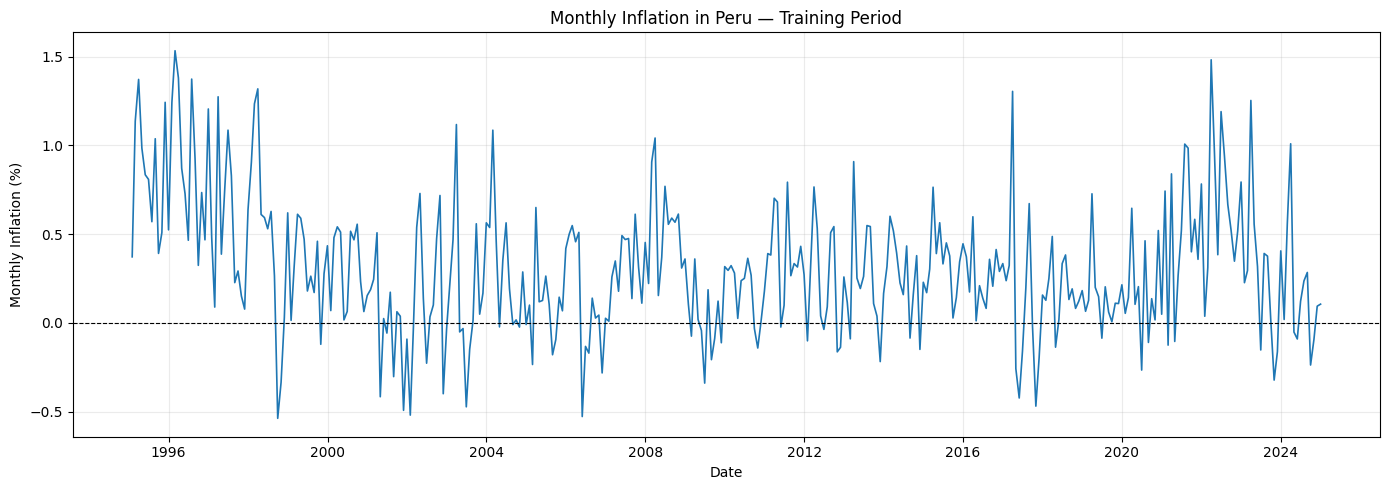

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    sarima_train.index,
    sarima_train["Inflation"],
    linewidth=1.2)

ax.axhline(
    y=0,
    color="black",
    linewidth=0.8,
    linestyle="--")

ax.set_title("Monthly Inflation in Peru — Training Period")
ax.set_xlabel("Date")
ax.set_ylabel("Monthly Inflation (%)")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
# Extract the training-period inflation series
inflation_train = sarima_train["Inflation"].copy()

# ADF test using training data only
run_adf_test(
    series=inflation_train,
    variable_name="Inflation — Training Period",
    regression="c")

ADF Test: Inflation — Training Period
Regression specification: c
ADF statistic: -3.8344
p-value: 0.0026
Lags used: 13
Observations: 346
Critical values:
  1%: -3.4494
  5%: -2.8699
  10%: -2.5712
Conclusion: Reject H₀. The result supports treating the series as stationary.


Only the training-period observations are plotted and tested for stationarity. The ADF test rejects the unit-root null hypothesis at the 5% significance level, with a statistic of −3.8344 and a p-value of 0.0026. Inflation is therefore treated as stationary and non-seasonal differencing is set to (d=0).

In [ ]:
# Extract the inflation series from the test dataset

inflation_test = sarima_test["Inflation"].copy()

print("Training observations:", len(inflation_train))
print("Test observations:", len(inflation_test))
print(
    "Test period:",
    inflation_test.index.min(),
    "to",
    inflation_test.index.max())

Training observations: 360
Test observations: 12
Test period: 2025-01-31 00:00:00 to 2025-12-31 00:00:00


**Model identification**

The training and test inflation series are stored separately. The ACF and PACF are then examined over 36 monthly lags, representing three complete annual cycles. The vertical reference lines identify seasonal lags at 12, 24 and 36 months.

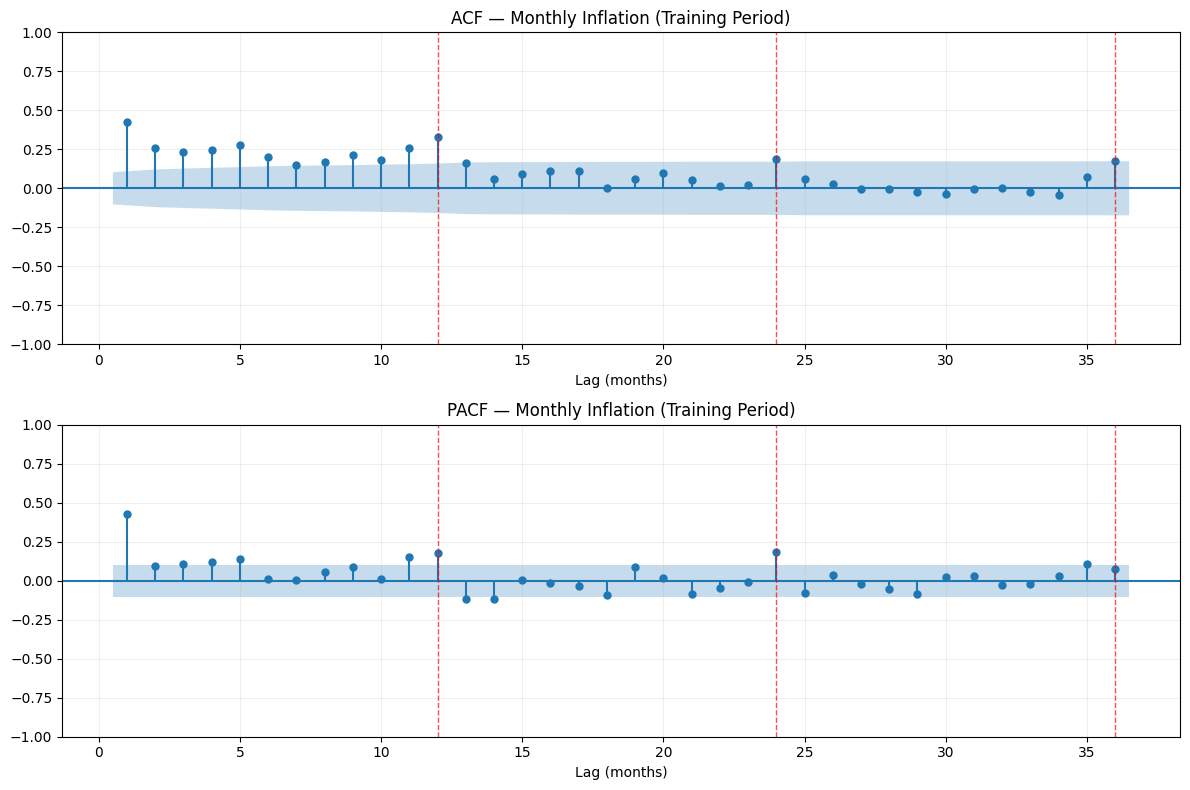

In [ ]:
# ACF and PACF of training-period inflation

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(
    inflation_train,
    lags=36,
    alpha=0.05,
    zero=False,
    ax=axes[0])

plot_pacf(
    inflation_train,
    lags=36,
    alpha=0.05,
    zero=False,
    method="ywm",
    ax=axes[1])

axes[0].set_title("ACF — Monthly Inflation (Training Period)")
axes[1].set_title("PACF — Monthly Inflation (Training Period)")

axes[0].set_xlabel("Lag (months)")
axes[1].set_xlabel("Lag (months)")

for ax in axes:
    ax.axvline(12, color="red", linestyle="--", linewidth=1, alpha=0.7)
    ax.axvline(24, color="red", linestyle="--", linewidth=1, alpha=0.7)
    ax.axvline(36, color="red", linestyle="--", linewidth=1, alpha=0.7)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Definition of candidate SARIMA models

The ACF and PACF suggest short-term persistence, supporting an AR(1) baseline. Correlation at annual lags also indicates that a seasonal component may be useful, although the plots do not clearly distinguish seasonal AR from MA effects.

A small set of candidates was therefore compared: the AR(1) baseline, seasonal AR and MA alternatives, and an ARMA(1,1) model with a seasonal AR term. All used d=0, D=0 and a seasonal period of 12. Seasonal differencing was not used because the plot and ACF did not indicate seasonal non-stationarity.

This block defines the candidates only. Selection later considers AIC, BIC, parsimony and residual diagnostics using training data.

**Preliminary candidate estimation**

The four initial candidates are estimated using the training series only. AIC and BIC are used to compare their relative fit while penalising additional parameters. Convergence status is also recorded.

In [ ]:
# Small candidate set supported by the training-series ACF and PACF

sarima_candidates = {
    "AR(1)": {
        "order": (1, 0, 0),
        "seasonal_order": (0, 0, 0, 12)},
    "AR(1) + seasonal AR(1)": {
        "order": (1, 0, 0),
        "seasonal_order": (1, 0, 0, 12)},
    "AR(1) + seasonal MA(1)": {
        "order": (1, 0, 0),
        "seasonal_order": (0, 0, 1, 12)},
    "ARMA(1,1) + seasonal AR(1)": {
        "order": (1, 0, 1),
        "seasonal_order": (1, 0, 0, 12)}
}

for name, specification in sarima_candidates.items():
    print(
        name + ":",
        "order=" + str(specification["order"]) + ",",
        "seasonal_order=" + str(specification["seasonal_order"]))

AR(1): order=(1, 0, 0), seasonal_order=(0, 0, 0, 12)
AR(1) + seasonal AR(1): order=(1, 0, 0), seasonal_order=(1, 0, 0, 12)
AR(1) + seasonal MA(1): order=(1, 0, 0), seasonal_order=(0, 0, 1, 12)
ARMA(1,1) + seasonal AR(1): order=(1, 0, 1), seasonal_order=(1, 0, 0, 12)


In [ ]:
# Estimate the candidate models using training data only

sarima_fits = {}
comparison_rows = []

for name, specification in sarima_candidates.items():
    try:
        model = SARIMAX(
            inflation_train,
            order=specification["order"],
            seasonal_order=specification["seasonal_order"],
            trend="c",
            enforce_stationarity=True,
            enforce_invertibility=True)

        fitted_model = model.fit(disp=False)

        sarima_fits[name] = fitted_model

        comparison_rows.append({
            "Model": name,
            "Order": specification["order"],
            "Seasonal Order": specification["seasonal_order"],
            "AIC": fitted_model.aic,
            "BIC": fitted_model.bic,
            "Converged": fitted_model.mle_retvals.get("converged", False)})

    except Exception as error:
        print(name + " could not be estimated:")
        print(error)

In [ ]:
# Create the comparison table

sarima_comparison = pd.DataFrame(comparison_rows)

sarima_comparison = (
    sarima_comparison
    .sort_values("AIC")
    .reset_index(drop=True))

sarima_comparison[["AIC", "BIC"]] = (
    sarima_comparison[["AIC", "BIC"]]
    .round(2))

sarima_comparison

,Model,Order,Seasonal Order,AIC,BIC,Converged
0,"ARMA(1,1) + seasonal AR(1)","(1, 0, 1)","(1, 0, 0, 12)",221.98,241.41,True
1,AR(1) + seasonal AR(1),"(1, 0, 0)","(1, 0, 0, 12)",229.76,245.31,True
2,AR(1) + seasonal MA(1),"(1, 0, 0)","(0, 0, 1, 12)",237.80,253.34,True
3,AR(1),"(1, 0, 0)","(0, 0, 0, 12)",255.35,267.01,True


**Preliminary residual autocorrelation test**

The Ljung–Box test is applied at lag 24, representing two annual seasonal cycles. The degrees-of-freedom adjustment reflects the number of non-seasonal and seasonal AR and MA terms in each model.

In [ ]:
# Ljung–Box residual autocorrelation test for all candidate models

ljung_box_rows = []

for name, fitted_model in sarima_fits.items():
    specification = sarima_candidates[name]

# Count the estimated AR and MA terms for the degrees-of-freedom adjustment
    model_df = (
        specification["order"][0]
        + specification["order"][2]
        + specification["seasonal_order"][0]
        + specification["seasonal_order"][2])

# Remove observations excluded from likelihood estimation
    residuals = fitted_model.resid.iloc[
        fitted_model.loglikelihood_burn:].dropna()

    lb_result = acorr_ljungbox(
        residuals,
        lags=[24],
        model_df=model_df,
        return_df=True)

    ljung_box_rows.append({
        "Model": name,
        "Lag": 24,
        "Model df": model_df,
        "Ljung-Box statistic": lb_result.loc[24, "lb_stat"],
        "p-value": lb_result.loc[24, "lb_pvalue"]})

# Create and format the comparison table

ljung_box_comparison = pd.DataFrame(ljung_box_rows)

ljung_box_comparison[["Ljung-Box statistic", "p-value"]] = (ljung_box_comparison[["Ljung-Box statistic", "p-value"]].round(4))

ljung_box_comparison

,Model,Lag,Model df,Ljung-Box statistic,p-value
0,AR(1),24,1,88.7476,0.0000
1,AR(1) + seasonal AR(1),24,2,57.6059,0.0001
2,AR(1) + seasonal MA(1),24,2,65.1437,0.0000
3,"ARMA(1,1) + seasonal AR(1)",24,3,45.3914,0.0015


**Preliminary residual autocorrelation results**

All four models had Ljung–Box p-values below 0.05 at lag 24, indicating residual autocorrelation in each case. The ARMA(1,1) model with a seasonal AR(1) term had the lowest statistic and highest p-value, consistent with its lower AIC and BIC values. However, its residuals still showed significant serial dependence. It was therefore retained as the leading candidate for further assessment, rather than selected as the final model at this stage.

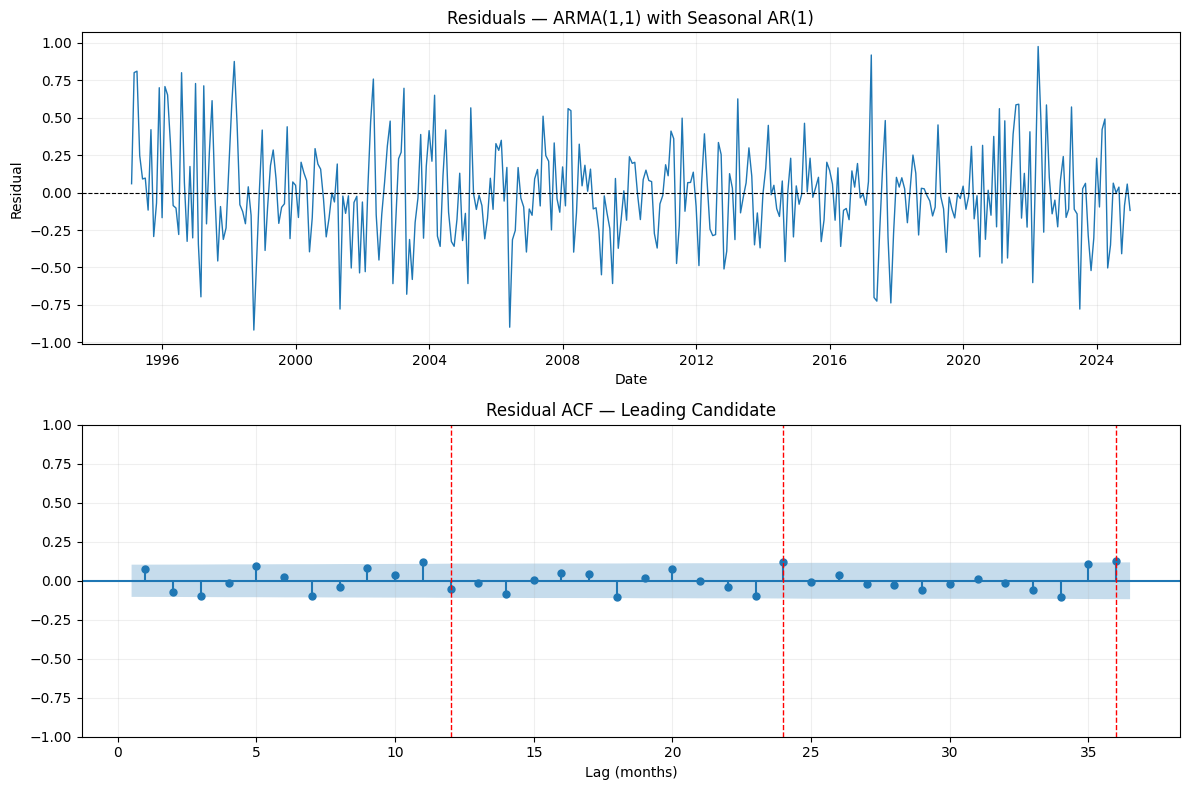

In [ ]:
# Residual inspection for the leading candidate

leading_model_name = "ARMA(1,1) + seasonal AR(1)"
leading_fit = sarima_fits[leading_model_name]

# Remove observations excluded from likelihood estimation
leading_residuals = leading_fit.resid.iloc[
    leading_fit.loglikelihood_burn:].dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(
    leading_residuals.index,
    leading_residuals,
    linewidth=1)

axes[0].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=0.8)

axes[0].set_title("Residuals — ARMA(1,1) with Seasonal AR(1)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Residual")
axes[0].grid(alpha=0.2)

plot_acf(
    leading_residuals,
    lags=36,
    zero=False,
    ax=axes[1])

axes[1].axvline(
    12,
    color="red",
    linestyle="--",
    linewidth=1)
axes[1].axvline(
    24,
    color="red",
    linestyle="--",
    linewidth=1)
axes[1].axvline(
    36,
    color="red",
    linestyle="--",
    linewidth=1)

axes[1].set_title("Residual ACF — Leading Candidate")
axes[1].set_xlabel("Lag (months)")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

**Residual inspection of the leading candidate**

Residuals were generally centred around zero, and most autocorrelations were within the 95% confidence bounds. However, small positive spikes appeared around lags 11, 24 and 36. Together with the significant Ljung–Box result, this suggests that some seasonal dependence remained.

The next comparison therefore considered limited seasonal extensions: a seasonal AR(2) term and a combined seasonal AR(1) and MA(1) specification. No wider model search was conducted.

In [ ]:
# Limited seasonal extensions based on the residual diagnostics

additional_candidates = {
    "ARMA(1,1) + seasonal AR(2)": {
        "order": (1, 0, 1),
        "seasonal_order": (2, 0, 0, 12)},
    "ARMA(1,1) + seasonal ARMA(1,1)": {
        "order": (1, 0, 1),
        "seasonal_order": (1, 0, 1, 12)}}

# Add the seasonal extensions to the candidate set

sarima_candidates.update(additional_candidates)

for name, specification in additional_candidates.items():
    print(
        name + ":",
        "order=" + str(specification["order"]) + ",",
        "seasonal_order=" + str(specification["seasonal_order"]))

ARMA(1,1) + seasonal AR(2): order=(1, 0, 1), seasonal_order=(2, 0, 0, 12)
ARMA(1,1) + seasonal ARMA(1,1): order=(1, 0, 1), seasonal_order=(1, 0, 1, 12)


In [ ]:
# Estimate only the two additional candidates using training data

for name, specification in additional_candidates.items():
    try:
        model = SARIMAX(
            inflation_train,
            order=specification["order"],
            seasonal_order=specification["seasonal_order"],
            trend="c",
            enforce_stationarity=True,
            enforce_invertibility=True)

        fitted_model = model.fit(disp=False)

        sarima_fits[name] = fitted_model

    except Exception as error:
        print(name + " could not be estimated:")
        print(error)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Create a comparison table for all successfully fitted candidates

comparison_rows = []

for name, fitted_model in sarima_fits.items():
    specification = sarima_candidates[name]

    comparison_rows.append({
        "Model": name,
        "Order": specification["order"],
        "Seasonal Order": specification["seasonal_order"],
        "AIC": fitted_model.aic,
        "BIC": fitted_model.bic,
        "Converged": fitted_model.mle_retvals.get(
            "converged",
            False)})

sarima_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("AIC")
    .reset_index(drop=True))

sarima_comparison[["AIC", "BIC"]] = (
    sarima_comparison[["AIC", "BIC"]]
    .round(2))

sarima_comparison

,Model,Order,Seasonal Order,AIC,BIC,Converged
0,"ARMA(1,1) + seasonal ARMA(1,1)","(1, 0, 1)","(1, 0, 1, 12)",169.46,192.77,False
1,"ARMA(1,1) + seasonal AR(2)","(1, 0, 1)","(2, 0, 0, 12)",210.01,233.33,True
2,"ARMA(1,1) + seasonal AR(1)","(1, 0, 1)","(1, 0, 0, 12)",221.98,241.41,True
3,AR(1) + seasonal AR(1),"(1, 0, 0)","(1, 0, 0, 12)",229.76,245.31,True
4,AR(1) + seasonal MA(1),"(1, 0, 0)","(0, 0, 1, 12)",237.80,253.34,True
5,AR(1),"(1, 0, 0)","(0, 0, 0, 12)",255.35,267.01,True


**Convergence assessment of the seasonal extensions**

The ARMA(1,1) model with seasonal ARMA(1,1) terms had the lowest AIC and BIC, but it did not converge. Its information criteria were therefore not considered reliable at this stage.

Among the converged models, ARMA(1,1) with seasonal AR(2) terms had the lowest AIC and BIC. The non-converged seasonal ARMA specification will be refitted once with a higher iteration limit before residual diagnostics are considered. This uses the same model and training data only.

In [ ]:
# Controlled refit of the non-converged candidate

nonconverged_name = "ARMA(1,1) + seasonal ARMA(1,1)"
nonconverged_spec = sarima_candidates[nonconverged_name]

refit_model = SARIMAX(
    inflation_train,
    order=nonconverged_spec["order"],
    seasonal_order=nonconverged_spec["seasonal_order"],
    trend="c",
    enforce_stationarity=True,
    enforce_invertibility=True)

# Refit the same specification with a higher iteration limit

refitted_seasonal_arma = refit_model.fit(
    method="lbfgs",
    maxiter=1000,
    disp=False)

print("Model:", nonconverged_name)
print(
    "Converged:",
    refitted_seasonal_arma.mle_retvals.get("converged", False))
print(
    "Iterations:",
    refitted_seasonal_arma.mle_retvals.get("iterations", "Not reported"))
print("AIC: {:.2f}".format(refitted_seasonal_arma.aic))
print("BIC: {:.2f}".format(refitted_seasonal_arma.bic))

print()
print("Optimizer details:")
print(refitted_seasonal_arma.mle_retvals)

Model: ARMA(1,1) + seasonal ARMA(1,1)
Converged: True
Iterations: 60
AIC: 169.45
BIC: 192.76

Optimizer details:
{'fopt': np.float64(0.21867566530847848), 'gopt': array([-0.07468575, -0.00271227,  0.00019024,  0.00180724,  0.000636  ,
        0.00202555]), 'fcalls': 588, 'warnflag': 0, 'converged': True, 'iterations': 60}


**Result of the controlled refit**

After increasing the maximum iterations, the ARMA(1,1) model with seasonal ARMA(1,1) terms converged after 60 iterations. Its AIC and BIC remained substantially lower than those of the other candidates, making it the leading specification at this stage.

Convergence alone does not confirm that the estimates are numerically reliable. The optimiser gradient and parameter estimates were therefore inspected before using the refitted model for residual diagnostics and final selection.

In [ ]:
# Inspect the numerical reliability of the refitted model

optimizer_gradient = np.asarray(
    refitted_seasonal_arma.mle_retvals.get("gopt", []))

print(
    "Converged:",
    refitted_seasonal_arma.mle_retvals.get("converged", False))

# Check the largest remaining optimiser gradient

if optimizer_gradient.size > 0:
    print(
        "Maximum absolute optimizer gradient:",
        "{:.6f}".format(np.max(np.abs(optimizer_gradient))))

# Inspect parameter estimates and their uncertainty

print()
print("Parameter estimates:")

parameter_table = pd.DataFrame({
    "Estimate": refitted_seasonal_arma.params,
    "Standard Error": refitted_seasonal_arma.bse,
    "p-value": refitted_seasonal_arma.pvalues})

display(parameter_table.round(6))

# Check whether AR and MA roots lie outside the unit circle

print()
print("Minimum AR-root modulus:")
print("{:.6f}".format(np.min(np.abs(refitted_seasonal_arma.arroots))))

print()
print("Minimum MA-root modulus:")
print("{:.6f}".format(np.min(np.abs(refitted_seasonal_arma.maroots))))

# Check for invalid numerical estimates

print()
print("Any non-finite parameter estimates:",(~np.isfinite(refitted_seasonal_arma.params)).any())

print("Any non-finite standard errors:",(~np.isfinite(refitted_seasonal_arma.bse)).any())

Converged: True
Maximum absolute optimizer gradient: 0.074686

Parameter estimates:


,Estimate,Standard Error,p-value
intercept,0.000142,0.000302,0.637478
ar.L1,0.973006,0.017826,0.000000
ma.L1,-0.767392,0.037670,0.000000
ar.S.L12,0.985085,0.017039,0.000000
ma.S.L12,-0.900195,0.060168,0.000000
sigma2,0.087907,0.006817,0.000000



Minimum AR-root modulus:
1.001253

Minimum MA-root modulus:
1.008800

Any non-finite parameter estimates: False
Any non-finite standard errors: False


**Numerical assessment of the refitted model**

The refitted seasonal ARMA specification produced finite parameter estimates and standard errors, while its AR and MA roots were outside the unit circle. It therefore passed the basic stationarity and invertibility checks.

However, the minimum root moduli were close to one. The seasonal AR and MA estimates were also large and opposite in sign, suggesting possible near-cancellation. The maximum optimiser gradient also remained relatively large despite reported convergence. This indicates potential numerical fragility.

Its lower AIC and BIC were therefore not treated as sufficient for final selection alone. The model was retained as the leading candidate and assessed with one final residual diagnostic. Final selection considered convergence, information criteria, residual behaviour and numerical fragility, without expanding the candidate set.

**Unified candidate-model comparison**

All successfully estimated candidate models were compared using AIC, BIC, convergence information, optimizer gradients, characteristic roots and the Ljung–Box test at lag 24. Standardized forecast errors were used for the residual-autocorrelation test.

In [ ]:
# Use the controlled converged refit for the seasonal ARMA candidate

leading_model_name = "ARMA(1,1) + seasonal ARMA(1,1)"
leading_fit = refitted_seasonal_arma

sarima_fits[leading_model_name] = leading_fit


def minimum_root_modulus(roots):
    """Return the smallest root modulus, or NaN when no roots exist."""

    roots = np.asarray(roots)

    if roots.size == 0:
        return np.nan

    return np.min(np.abs(roots))


diagnostic_rows = []

for name, fitted_model in sarima_fits.items():
    specification = sarima_candidates[name]

    # Count AR and MA terms for the Ljung–Box degrees-of-freedom adjustment
    model_df = (
        specification["order"][0]
        + specification["order"][2]
        + specification["seasonal_order"][0]
        + specification["seasonal_order"][2])

    # Record the largest remaining optimiser gradient
    optimizer_gradient = np.asarray(
        fitted_model.mle_retvals.get("gopt", []))

    if optimizer_gradient.size > 0:
        max_gradient = np.max(np.abs(optimizer_gradient))
    else:
        max_gradient = np.nan

    # Extract standardised one-step-ahead forecast errors
    standardized_errors = np.asarray(
        fitted_model.filter_results.standardized_forecasts_error[0])

    burn = max(
        int(fitted_model.loglikelihood_burn),
        int(getattr(fitted_model.filter_results, "nobs_diffuse", 0)))

    standardized_residuals = pd.Series(
        standardized_errors[burn:],
        index=inflation_train.index[burn:])

    standardized_residuals = (
        standardized_residuals
        .replace([np.inf, -np.inf], np.nan)
        .dropna())

    # Test residual autocorrelation after two seasonal cycles
    lb_result = acorr_ljungbox(
        standardized_residuals,
        lags=[24],
        model_df=model_df,
        return_df=True)

    diagnostic_rows.append({
        "Model": name,
        "Order": specification["order"],
        "Seasonal Order": specification["seasonal_order"],
        "AIC": fitted_model.aic,
        "BIC": fitted_model.bic,
        "Converged": fitted_model.mle_retvals.get("converged", False),
        "Maximum Absolute Gradient": max_gradient,
        "Minimum AR-Root Modulus": minimum_root_modulus(
            fitted_model.arroots),
        "Minimum MA-Root Modulus": minimum_root_modulus(
            fitted_model.maroots),
        "Ljung–Box Statistic (Lag 24)": lb_result.loc[24, "lb_stat"],
        "Ljung–Box p-value": lb_result.loc[24, "lb_pvalue"]
    })

# Create and format the diagnostic comparison table

sarima_diagnostics = (
    pd.DataFrame(diagnostic_rows)
    .sort_values("AIC")
    .reset_index(drop=True))

display(
    sarima_diagnostics.style.format({
        "AIC": "{:.2f}",
        "BIC": "{:.2f}",
        "Maximum Absolute Gradient": "{:.6f}",
        "Minimum AR-Root Modulus": "{:.6f}",
        "Minimum MA-Root Modulus": "{:.6f}",
        "Ljung–Box Statistic (Lag 24)": "{:.4f}",
        "Ljung–Box p-value": "{:.6f}"
    }, na_rep="N/A"))

,Model,Order,Seasonal Order,AIC,BIC,Converged,Maximum Absolute Gradient,Minimum AR-Root Modulus,Minimum MA-Root Modulus,Ljung–Box Statistic (Lag 24),Ljung–Box p-value
0,"ARMA(1,1) + seasonal ARMA(1,1)","(1, 0, 1)","(1, 0, 1, 12)",169.45,192.76,True,0.074686,1.001253,1.008800,43.7381,0.001631
1,"ARMA(1,1) + seasonal AR(2)","(1, 0, 1)","(2, 0, 0, 12)",210.01,233.33,True,0.000171,1.046638,1.645926,47.9278,0.000435
2,"ARMA(1,1) + seasonal AR(1)","(1, 0, 1)","(1, 0, 0, 12)",221.98,241.41,True,0.000009,1.115575,1.606041,45.5626,0.001460
3,AR(1) + seasonal AR(1),"(1, 0, 0)","(1, 0, 0, 12)",229.76,245.31,True,0.000005,1.110374,N/A,56.9485,0.000062
4,AR(1) + seasonal MA(1),"(1, 0, 0)","(0, 0, 1, 12)",237.80,253.34,True,0.000058,2.562773,1.139951,64.7614,0.000004
5,AR(1),"(1, 0, 0)","(0, 0, 0, 12)",255.35,267.01,True,0.000018,2.345316,N/A,88.7356,0.000000


**Residual diagnostics for the leading SARIMA specification**

The standardized residuals of the leading specification are examined using diagnostic plots, the Jarque–Bera normality test and a break-in-variance test. These checks assess the distribution, autocorrelation and variance stability of the model errors before final model selection.

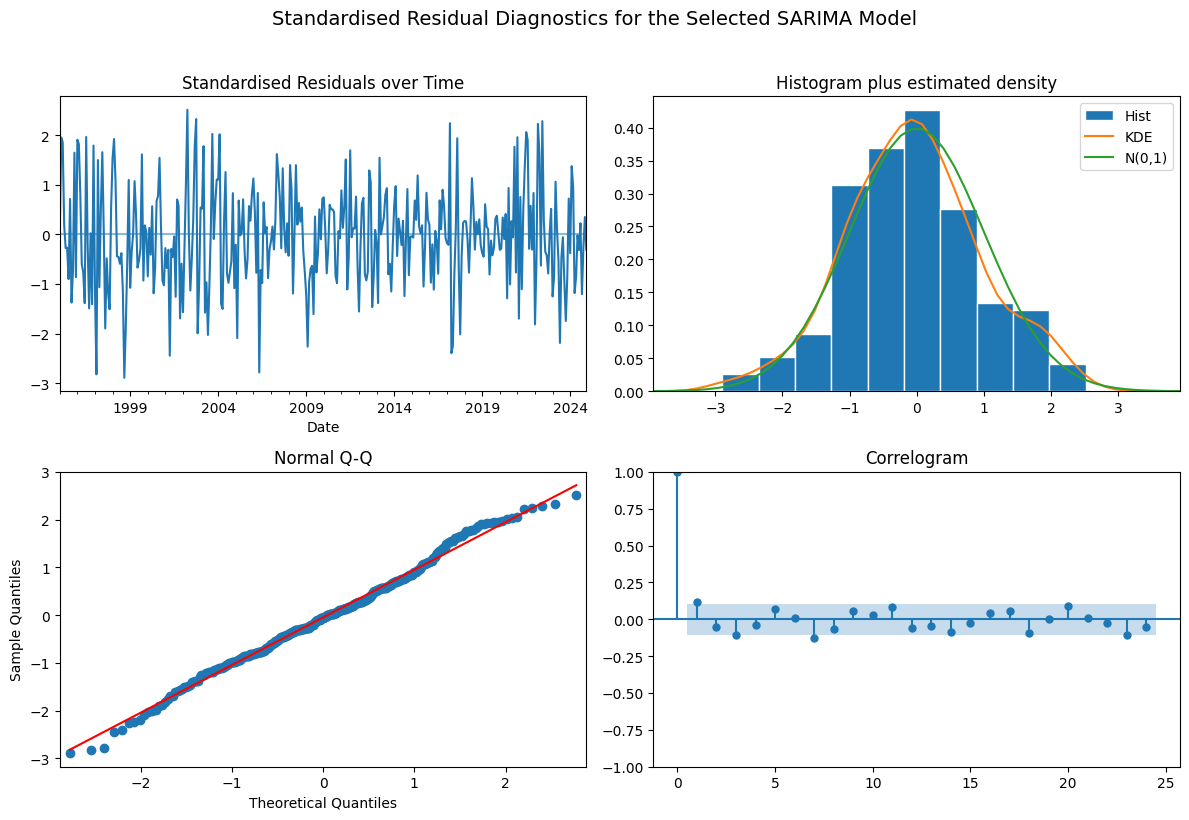

In [ ]:
# Retain the selected model from the controlled candidate set

selected_sarima_fit = refitted_seasonal_arma

# Plot four standard diagnostics using standardised residuals

diagnostic_figure = selected_sarima_fit.plot_diagnostics(
    figsize=(12, 8),
    lags=24)

diagnostic_figure.axes[0].set_title("Standardised Residuals over Time")

diagnostic_figure.suptitle("Standardised Residual Diagnostics for the Selected SARIMA Model",fontsize=14,y=1.02)

plt.tight_layout()
plt.show()

In [ ]:
# Test whether standardised residuals are normally distributed

normality_result = selected_sarima_fit.test_normality(
    method="jarquebera")[0]

# Test whether residual variance remains constant over time

variance_result = selected_sarima_fit.test_heteroskedasticity(
    method="breakvar",
    alternative="two-sided",
    use_f=True)[0]

# Create a summary table of residual diagnostic results

residual_test_results = pd.DataFrame({
    "Diagnostic": [
        "Jarque–Bera Normality Test",
        "Break-in-Variance Test"],
    "Test Statistic": [
        normality_result[0],
        variance_result[0]],
    "p-value": [
        normality_result[1],
        variance_result[1]],
    "Null Hypothesis": [
        "The standardised residuals are normally distributed",
        "The standardised residuals have constant variance"]
})

display(
    residual_test_results.style.format({
        "Test Statistic": "{:.4f}",
        "p-value": "{:.6f}"
    }))

,Diagnostic,Test Statistic,p-value,Null Hypothesis
0,Jarque–Bera Normality Test,0.1412,0.931835,The standardised residuals are normally distributed
1,Break-in-Variance Test,0.6184,0.008940,The standardised residuals have constant variance


The Jarque–Bera test did not reject residual normality at the 5% level. However, the break-in-variance test rejected constant variance. Together with the significant Ljung–Box result, this indicates remaining autocorrelation and variance instability. The diagnostics were therefore not fully satisfactory, so forecasts and prediction intervals should be interpreted with caution.

# Final SARIMA model selection

Of the six models evaluated, the refitted SARIMA (1,0,1)(1,0,1)12 had the lowest AIC and BIC. It converged after increasing the iteration limit, and its AR and MA roots were outside the unit circle.

However, diagnostics indicated some numerical fragility. The minimum root moduli were close to one, the seasonal AR and MA terms suggested possible near-cancellation, and the optimiser gradient remained relatively large. The Ljung–Box test also indicated residual autocorrelation at lag 24 (p=0.0016), while the break-in-variance test suggested non-constant residual variance. The Jarque–Bera test did not reject residual normality.

The model was therefore selected within the controlled candidate set because it had the lowest information criteria, despite diagnostics not being fully satisfactory. Selection used training data only, and these limitations were considered when interpreting its forecasts and prediction intervals.

# Out-of-sample SARIMA forecasting

The selected SARIMA model was used to generate forecasts for January–December 2025. These 12 observations were excluded from model estimation and selection, providing an out-of-sample evaluation of forecast performance. The point forecasts and 95% prediction intervals were aligned with the corresponding test-period dates.

In [ ]:
# Generate the 12-month out-of-sample SARIMA forecasts

final_sarima_name = "ARMA(1,1) + seasonal ARMA(1,1)"
final_sarima_fit = refitted_seasonal_arma

assert len(inflation_test) == 12, (
    "The test set should contain exactly 12 observations.")

# Generate forecasts and 95% prediction intervals for the test period

forecast_result = final_sarima_fit.get_forecast(
    steps=len(inflation_test))

sarima_forecast = forecast_result.predicted_mean.copy()
forecast_interval = forecast_result.conf_int(alpha=0.05).copy()

# Align forecasts with the held-out test-period dates

sarima_forecast.index = inflation_test.index
forecast_interval.index = inflation_test.index

forecast_comparison = pd.DataFrame({
    "Actual Inflation": inflation_test,
    "SARIMA Forecast": sarima_forecast,
    "Lower 95% PI": forecast_interval.iloc[:, 0],
    "Upper 95% PI": forecast_interval.iloc[:, 1]})

display(forecast_comparison.round(4))

,Actual Inflation,SARIMA Forecast,Lower 95% PI,Upper 95% PI
Date,,,,
2025-01-31,-0.0933,0.0531,-0.5280,0.6343
2025-02-28,0.1880,0.1371,-0.4563,0.7304
2025-03-31,0.8102,0.6185,0.0139,1.2231
2025-04-30,0.3181,0.0967,-0.5184,0.7118
2025-05-31,-0.0565,0.0404,-0.5845,0.6653
2025-06-30,0.1287,0.0756,-0.5584,0.7096
2025-07-31,0.2314,0.2709,-0.3716,0.9134
2025-08-31,-0.2903,0.1919,-0.4585,0.8423
2025-09-30,0.0112,0.0485,-0.6093,0.7064


# SARIMA forecast evaluation

Forecast accuracy was evaluated using RMSE, MAE and MAPE. RMSE gives greater weight to larger forecast errors, while MAE shows the average absolute error in monthly inflation percentage points.

MAPE was included for consistency with the planned comparison. However, because monthly inflation can be negative or close to zero, its percentage errors may become very large and should be interpreted cautiously.

In [ ]:
# Calculate SARIMA forecast accuracy metrics

actual_values = forecast_comparison["Actual Inflation"]
forecast_values = forecast_comparison["SARIMA Forecast"]

sarima_rmse = np.sqrt(
    mean_squared_error(
        actual_values,
        forecast_values))

sarima_mae = mean_absolute_error(
    actual_values,
    forecast_values)

# Exclude exact zeros because percentage error is undefined

nonzero_mask = actual_values != 0

sarima_mape = (
    np.mean(
        np.abs(
            (actual_values[nonzero_mask]
             - forecast_values[nonzero_mask])
            / actual_values[nonzero_mask]))
    * 100)

print("Final model:", final_sarima_name)
print("RMSE: {:.4f}".format(sarima_rmse))
print("MAE: {:.4f}".format(sarima_mae))
print("MAPE: {:.2f}%".format(sarima_mape))

print(
    "Observations used for MAPE:",
    int(nonzero_mask.sum()),
    "of",
    len(actual_values))

Final model: ARMA(1,1) + seasonal ARMA(1,1)
RMSE: 0.1767
MAE: 0.1275
MAPE: 99.34%
Observations used for MAPE: 12 of 12


**Comparison with simple forecasting benchmarks**

The selected SARIMA model was compared with mean, naïve and seasonal-naïve forecasts. These benchmarks were included to determine whether the more complex model provided an improvement in out-of-sample forecast accuracy.

In [ ]:
# Prepare actual values and benchmark forecasts

benchmark_actuals = np.asarray(
    actual_values,
    dtype=float).reshape(-1)

benchmark_forecasts = {
    "Selected SARIMA": np.asarray(
        forecast_values,
        dtype=float).reshape(-1),
    "Seasonal-naïve": np.asarray(
        inflation_train.iloc[-12:],
        dtype=float).reshape(-1),
    "Naïve last value": np.full(
        len(benchmark_actuals),
        float(inflation_train.iloc[-1])),
    "Mean forecast": np.full(
        len(benchmark_actuals),
        float(inflation_train.mean()))}

In [ ]:
# Calculate RMSE and MAE for each forecasting method

benchmark_rows = []

for method, predictions in benchmark_forecasts.items():
    if len(predictions) != len(benchmark_actuals):
        raise ValueError(
            "{} produced {} forecasts; {} were expected.".format(
                method,
                len(predictions),
                len(benchmark_actuals)))

    benchmark_rows.append({
        "Method": method,
        "RMSE": np.sqrt(
            mean_squared_error(benchmark_actuals, predictions)),
        "MAE": mean_absolute_error(
            benchmark_actuals, predictions)})

In [ ]:
# Create and format the benchmark comparison table

benchmark_results = (
    pd.DataFrame(benchmark_rows)
    .sort_values("RMSE")
    .reset_index(drop=True))

display(
    benchmark_results.style.format({
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}"}))

,Method,RMSE,MAE
0,Selected SARIMA,0.1767,0.1275
1,Seasonal-naïve,0.2480,0.1735
2,Naïve last value,0.2673,0.1957
3,Mean forecast,0.3231,0.2680


The selected SARIMA model had the lowest RMSE and MAE among the four forecasting methods for January–December 2025. Compared with the seasonal-naïve method, the strongest simple benchmark, it reduced RMSE by approximately 28.8% and MAE by 26.5%. This suggests that SARIMA provided additional forecasting value during the test period. However, the comparison is based on only 12 monthly observations, so it does not show that SARIMA would consistently outperform the benchmarks in other periods.

# Interpretation of SARIMA forecast accuracy

The selected SARIMA model recorded an RMSE of 0.1767 and an MAE of 0.1275 over the 12-month test period. This means that its forecasts differed from actual monthly inflation by approximately 0.13 percentage points on average. The higher RMSE reflects the greater weight this measure gives to larger forecast errors.

MAPE was 99.34%, but it does not provide a reliable summary of accuracy in this case. The test period included negative and near-zero inflation values, which can produce disproportionately large percentage errors. MAPE is therefore reported for consistency with the planned model comparison, while RMSE and MAE are used as the main evaluation measures.

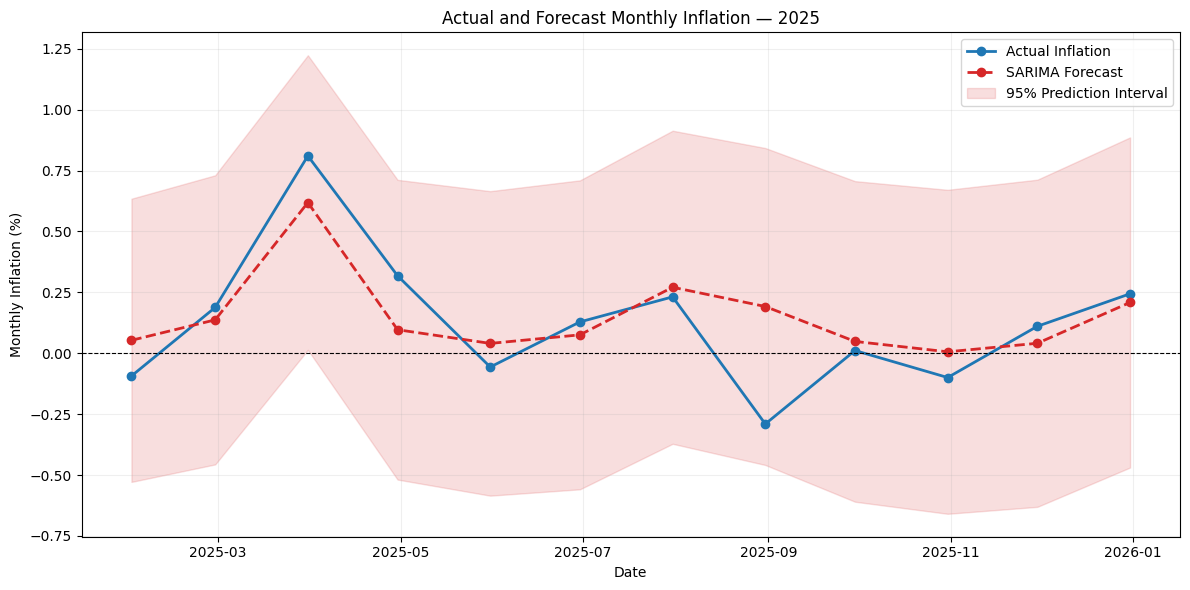

In [ ]:
# Actual and forecast monthly inflation

plt.figure(figsize=(12, 6))

# Plot actual and forecast monthly inflation

plt.plot(
    forecast_comparison.index,
    forecast_comparison["Actual Inflation"],
    marker="o",
    linewidth=2,
    label="Actual Inflation",
    color="#1f77b4")

plt.plot(
    forecast_comparison.index,
    forecast_comparison["SARIMA Forecast"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="SARIMA Forecast",
    color="#d62728")

# Add the 95% prediction interval

plt.fill_between(
    forecast_comparison.index,
    forecast_comparison["Lower 95% PI"],
    forecast_comparison["Upper 95% PI"],
    color="#d62728",
    alpha=0.15,
    label="95% Prediction Interval")

# Mark the zero-inflation reference line

plt.axhline(
    0,
    color="black",
    linewidth=0.8,
    linestyle="--")

plt.title("Actual and Forecast Monthly Inflation — 2025")
plt.xlabel("Date")
plt.ylabel("Monthly Inflation (%)")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

**Interpretation of the out-of-sample forecasts**

The SARIMA forecasts captured the rise in inflation in March and some lower values later in 2025. However, the model underestimated inflation in March and April and forecast positive inflation in January, May, August and October, when the actual values were negative.

All 12 actual values were within the 95% prediction intervals, although these were relatively wide. RMSE (0.1767) and MAE (0.1275) were the most useful accuracy measures. MAPE was less reliable because several actual values were negative or close to zero.

SARIMA outperformed the three simple benchmarks, including the seasonal-naïve method. However, the test period included only 12 observations, so this does not show that SARIMA would perform better in other periods. Its wide intervals, residual autocorrelation, variance instability and numerical fragility should also be considered.